# Solution 6B: Drawdown Analysis
**BUSI 722: Data-Driven Finance II**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

preds = pd.read_parquet("expanding_predictions.parquet")
preds["u"] = preds.groupby("month")["pred"].transform(lambda x: x.rank(pct=True))
smooth_ret = pd.read_parquet("smooth_portfolio_returns.parquet")
print(f"Predictions: {len(preds):,} rows")
print(f"Smooth returns: {len(smooth_ret)} months")

Predictions: 66,121 rows
Smooth returns: 23 months


## Setup: Compute portfolio returns

In [2]:
# D10 long-only
preds["decile"] = preds.groupby("month")["pred"].transform(
    lambda x: pd.qcut(x, 10, labels=False, duplicates="drop") + 1)
d10_ret = preds[preds["decile"] == preds["decile"].max()].groupby("month")["return"].mean().sort_index()

## 1-4. Linear long-short drawdown

In [3]:
def drawdown_analysis(returns, name):
    cum = (1 + returns).cumprod()
    peak = cum.cummax()
    dd = (cum - peak) / peak
    print(f"{name}:")
    print(f"  Max drawdown: {dd.min():.2%}")
    if hasattr(dd, 'idxmin'):
        trough = dd.idxmin()
        peak_date = cum.iloc[:list(dd.index).index(trough)+1].idxmax()
        print(f"  Peak: {peak_date}, Trough: {trough}")
        recovery = cum.iloc[list(dd.index).index(trough):]
        recovered = recovery[recovery >= cum.loc[peak_date]]
        print(f"  Recovery: {recovered.index[0] if len(recovered) > 0 else 'Not recovered'}")
    print(f"  5 worst months:")
    for idx, val in returns.nsmallest(5).items():
        print(f"    {idx}: {val:.2%}")
    return dd

common = sorted(set(smooth_ret.index) & set(d10_ret.index))
ls_dd = drawdown_analysis(smooth_ret.loc[common, "Linear"], "Linear Long-Short")
print()
d10_dd = drawdown_analysis(d10_ret.loc[common], "Long-Only Top Decile")

Linear Long-Short:
  Max drawdown: -4.01%
  Peak: 2025-04, Trough: 2025-10
  Recovery: Not recovered
  5 worst months:
    2024-12: -1.59%
    2025-09: -1.52%
    2025-10: -1.21%
    2025-06: -0.75%
    2025-07: -0.44%

Long-Only Top Decile:
  Max drawdown: -13.12%
  Peak: 2024-11, Trough: 2025-04
  Recovery: 2025-08
  5 worst months:
    2024-12: -8.07%
    2025-03: -6.20%
    2024-04: -6.15%
    2025-10: -2.84%
    2025-09: -2.75%


## Underwater chart

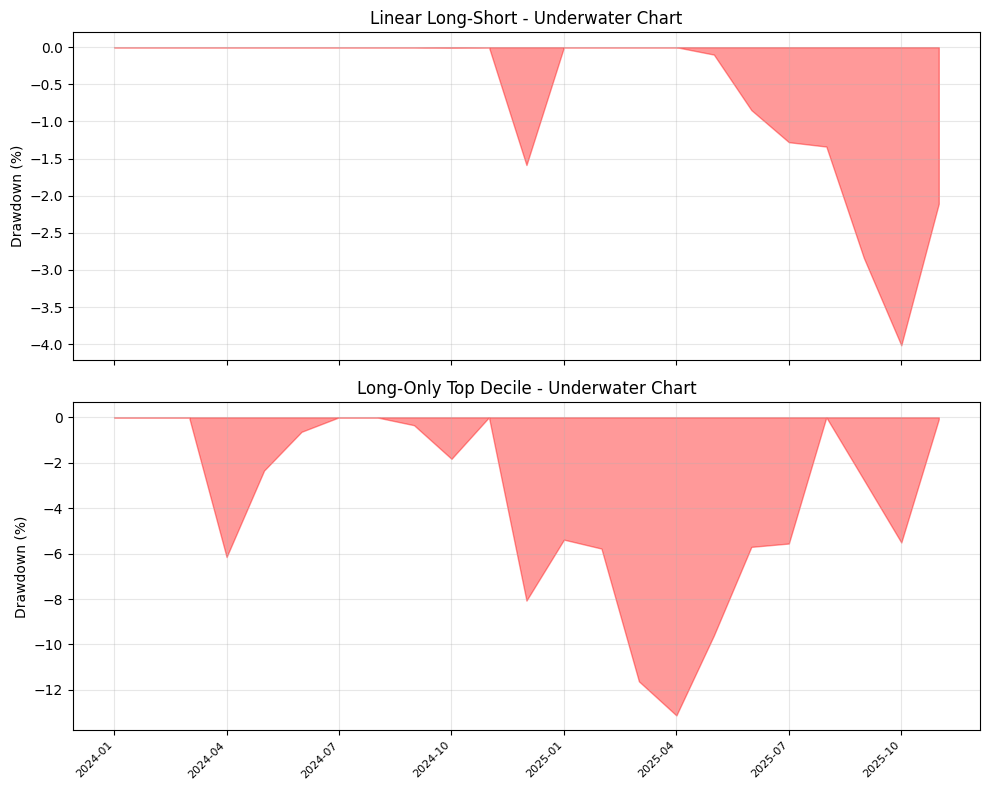

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
for ax, dd, title in [(axes[0], ls_dd, "Linear Long-Short"),
                       (axes[1], d10_dd, "Long-Only Top Decile")]:
    ax.fill_between(range(len(dd)), dd.values * 100, 0, color="red", alpha=0.4)
    ax.set_title(f"{title} - Underwater Chart")
    ax.set_ylabel("Drawdown (%)")
    ax.grid(True, alpha=0.3)
ticks = list(range(0, len(common), max(1, len(common) // 6)))
axes[1].set_xticks(ticks)
axes[1].set_xticklabels([common[i] for i in ticks], rotation=45, ha="right", fontsize=8)
plt.tight_layout()
plt.show()

## 5. Discussion

The long-only portfolio tends to have deeper drawdowns because it is fully exposed to market risk. The long-short portfolio hedges out much of the market exposure, resulting in shallower drawdowns but potentially longer recovery periods.